# Training and deployment of a YOLO11 model for Pose Estimation

## 🌟 Overview

In this tutorial, you will learn how to work with the YOLO11 keypoint detection model from Ultralytics. We’ll guide you through downloading, training, and deploying the model on a Luxonis device, with clear code comments to help you follow along.

## 📜 Table of Contents
- [🛠️ Installation](#️installation)
- [🗃️ Data Preparation](#data-preparation)
- [🏋️‍♂️ Training](#️️training)
- [✍ Validation](#validation)
- [🧠 Infer](#infer)
- [🗂️ Conversion](#conversion)
- [📷 DepthAI Script](#depthai-script)

<a name="️installation"></a>

## 🛠️ Installation

We'll install all the dependencies we'll need.

In [ ]:
%pip install -q ultralytics -U
%pip install -q depthai==3.7.1
%pip install -q depthai-nodes==0.5.1

<a name ="data-preparation"></a>

## 🗃️ Data Preparation


If you use a custom dataset, you must prepare your dataset for training. Once you have set up a YAML file and sorted labels and images into the right directories, you can continue with the next step.

Luckily, we will be using `COCO8 Pose`, for which YAML already exists. You can check it out [here](https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/coco8-pose.yaml).

In case you need to train on a custom dataset, please follow these steps:

#### 1. Prepare your own dataset with images
#### 2. Generate label files in YOLO format

One image corresponds to one label file. Object information per row. Each row contains the following information about the object instance:

- Object class index: An integer representing the class of the object (e.g., 0 for person, 1 for car, etc.).
- Object center coordinates: The x and y coordinates of the center of the object, normalized to be between 0 and 1.
- Object width and height: The width and height of the object, normalized to be between 0 and 1.
- Object keypoint coordinates: The keypoints of the object, normalized to be between 0 and 1.

The label format example is below.

- Format with Dim = 2
```txt
<class-index> <x> <y> <width> <height> <px1> <py1> <px2> <py2> ... <pxn> <pyn>
```
- Format with Dim = 3
```txt
<class-index> <x> <y> <width> <height> <px1> <py1> <p1-visibility> <px2> <py2> <p2-visibility> <pxn> <pyn> <p2-visibility>
```

#### 3. Organize directories and create the `.yaml` file.

The config `.yaml` file should have the following structure:
```yaml
# Train/val/test sets as
# 1) dir: path/to/imgs
# 2) file: path/to/imgs.txt, or
# 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: ../dataset/
train: # train images (relative to 'path')
val: # val images (relative to 'path')
test: # test images (optional)

# Keypoints
kpt_shape: [17, 3] # number of keypoints, number of dims (2 for x,y or 3 for x,y,visible)
# flip_idx: ... # Optional, flip indices, for more details see https://docs.ultralytics.com/datasets/pose/#dataset-yaml-format

# Classes
names:
  0: [class-0]
  1: [class-1]
  ...

# Download script/URL (optional)
download:
```

For more details about the format, please refer to [this](https://docs.ultralytics.com/datasets/pose/) page.


<a name ="️️training"></a>

## 🏋️‍♂️ Training


Before we begin the training, we have to choose the pre-trained model. This image from `Ultralytics` documentation quickly summarizes them. You can find more about the models [here](https://docs.ultralytics.com/tasks/pose/#models).

<img src="./media/model_zoo.png" alt="YOLO11 Pose Estimation model variants selection" width="720">

We select the `YOLO11n` as it is the smallest and quickest. You can also experiment with heavier models, but it might affect the FPS on our devices.

In [ ]:
from ultralytics import YOLO

# Load a pretrained model (recommended for training)
model = YOLO("yolo11n-pose.pt")

We will set image size *img* to *640*. We will train the model for *2* *epochs*. We set *data* to `coco8-pose.yaml`.

For the actual training, *epochs* should be higher (typically between *300-1000* epochs).

In [ ]:
# Train the model
results = model.train(data="coco8-pose.yaml", epochs=2, imgsz=640)

<a name ="validation"></a>

## ✍ Validation

After training our model, we can validate it on the validation set of our dataset.

In [ ]:
metrics = model.val()

<a name ="infer"></a>

## 🧠 Infer

Usually, we also want to visualize the prediction of the trained model on some image to ensure it does what it is supposed to do. This is called inference, and we'll perform it on one image.


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 86.5ms
Speed: 5.5ms preprocess, 86.5ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 480)


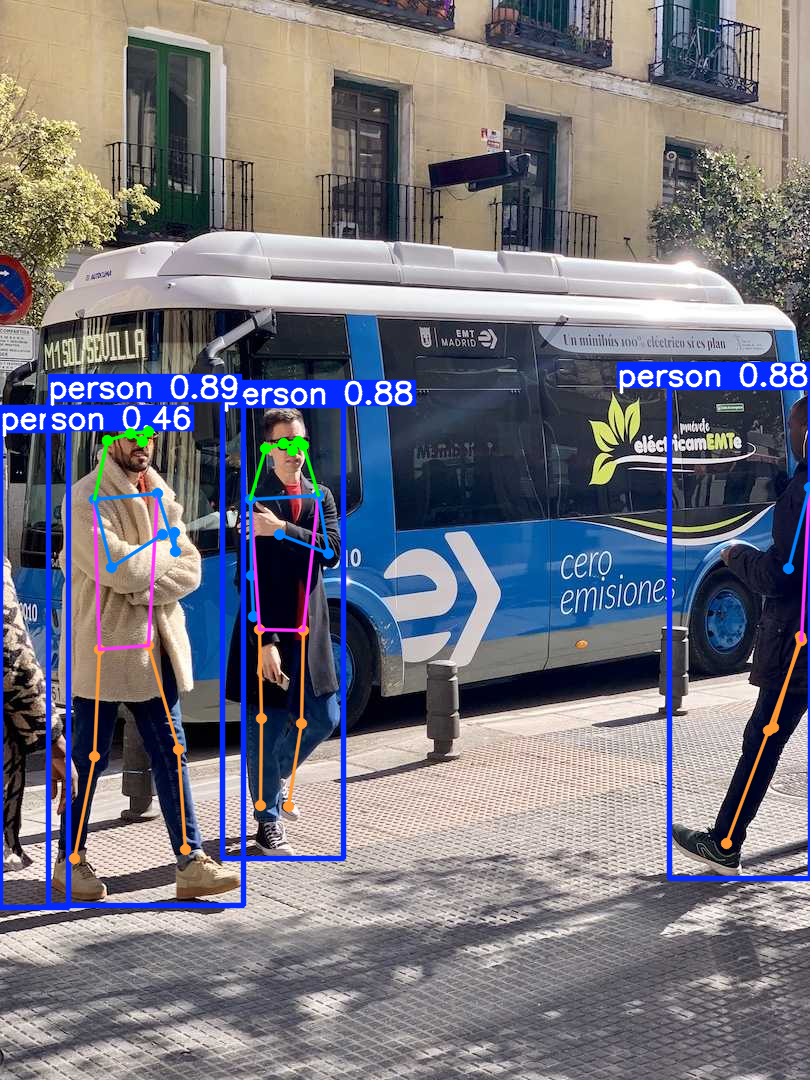

In [6]:
results = model("https://ultralytics.com/images/bus.jpg")  # Predict on an image
results[0].show() # Show the results

<a name="conversion"></a>

## 🗂️ Conversion

By default, the library saves the weights with the best performance into the `best.pt` file inside the corresponding run folder. We'll rename it to reflect the model better.

In [ ]:
import shutil

shutil.copy("runs/pose/train/weights/best.pt", "yolo11n_pose_trained.pt")

If you are experiencing the following error:

```
NotImplementedError: A UTF-8 locale is required. Got ANSI_X3.4-1968
```

Please run the following command and rerun the previous command:

```python
import locale
locale.getpreferredencoding = lambda: "UTF-8"
```

We have the trained model, and the goal is to deploy it to the Luxonis device. The model's specific format depends on the Luxonis device series you have. We will show you how to use our [`HubAI SDK`](https://github.com/luxonis/hubai-sdk) to convert the model as simply as possible. 

We'll start by installing the `HubAI SDK`.

In [ ]:
%pip install -q -U hubai-sdk

We will use the `HubAI SDK` Python API, which leverages our [`HubAI`](https://hub.luxonis.com) platform to perform model conversion in the background. To get started, you'll need to create an account on `HubAI` and obtain your team’s API key.

In [ ]:
import os
from getpass import getpass

HUBAI_API_KEY = getpass("Enter your HubAI API key: ")
os.environ["HUBAI_API_KEY"] = HUBAI_API_KEY

if not HUBAI_API_KEY:
    raise RuntimeError("HubAI API key is required.")

Model conversion can be done via either the CLI or the Python API — here, we'll use the latter. For more information, see the [HubAI SDK documentation](https://github.com/luxonis/hubai-sdk).

The call below creates a new model card within your team on `HubAI`, uploads the model file and metadata, then performs cloud-side conversion to the selected target platform (e.g., [`RVC2`](https://rvc4.docs.luxonis.com/hardware/platform/rvc/rvc2/), [`RVC4`](https://rvc4.docs.luxonis.com/hardware/platform/rvc/rvc4/)). Once completed, the converted model is automatically downloaded to your device.

For HubAI-specific conversion parameters, refer to the [parameter documentation](https://github.com/luxonis/hubai-sdk/blob/main/docs/available_parameters.md#model-parameters). Platform-specific parameters are also documented there.


In [ ]:
from hubai_sdk import HubAIClient

client = HubAIClient(api_key=HUBAI_API_KEY)

response = client.convert.RVC2(
    path="runs/train/exp/weights/yolov6ntrained.pt",
    path="yolo11n_pose_trained.pt",
    name="YOLO11 Nano COCO8 Pose Estimation",
    description_short="Trained YOLO11 nano pose estimation model on COCO8 dataset.",
    yolo_version="yolov11",
    yolo_input_shape=[512, 288],
    yolo_class_names=["person"],
    tasks=["KEYPOINT_DETECTION"],
    license_type="MIT",
    is_public=False
)

converted_model_path = response.downloaded_path

We have successfully converted our trained model for an RVC2 device, so let's test it! Please copy the path to the downloaded archive with the converted model from the output log of the last code cell; we will use it in the next section.

In [ ]:
from pathlib import Path

if "converted_model_path" in globals():
    MODEL_PATH = Path(converted_model_path)
elif "response" in globals():
    MODEL_PATH = Path(response.downloaded_path)
else:
    output_dir = Path("yolo11n-pose-coco8-exported-to-rvc2")
    archives = sorted(output_dir.glob("*.tar.xz"))

    if not archives:
        raise FileNotFoundError(
            "No converted model archive found. Run the HubAI conversion cell first, "
            "or set MODEL_PATH manually to the downloaded .tar.xz archive."
        )

    MODEL_PATH = archives[0]

print("Using model:", MODEL_PATH)

<a name="depthai-script"></a>

## 📷 DepthAI Script

To test our model on one of our cameras, we need to have `DepthAI v3` and `Depthai Nodes` installed. Moreover, the following script must be run locally and requires a Luxonis device connected to your machine.

To run the model on a DepthAI device using the script below, please note the following:

- You can view the output stream by opening [http://localhost:8082](http://localhost:8082) in your browser.

- If you're running the script from a Jupyter Notebook, the output may not appear directly within the notebook. The script should print a link pointing to [http://localhost:8082](http://localhost:8082) for accessing the stream.

- To stop the video stream, press **`q`** while focused on the visualizer page.

In [ ]:
DEVICE = None # Set to None to use the default device, or you can specify a specific device IP

In [ ]:
from depthai_nodes.node import ParsingNeuralNetwork
import depthai as dai

device = dai.Device(dai.DeviceInfo(DEVICE)) if DEVICE else dai.Device()
platform = device.getPlatform()
img_frame_type = dai.ImgFrame.Type.BGR888i if platform.name == "RVC4" else dai.ImgFrame.Type.BGR888p
visualizer = dai.RemoteConnection(httpPort=8082)

with dai.Pipeline(device) as pipeline:
    cam = pipeline.create(dai.node.Camera).build()
    nn_archive = dai.NNArchive(MODEL_PATH)
    # Create the neural network node
    nn_with_parser = pipeline.create(ParsingNeuralNetwork).build(
        cam.requestOutput((512, 384), type=img_frame_type, fps=30), 
        nn_archive
    )
    # Configure the visualizer node
    visualizer.addTopic("Video", nn_with_parser.passthrough, "images")
    visualizer.addTopic("Detections", nn_with_parser.out, "detections")

    # Start pipeline
    pipeline.start()
    visualizer.registerPipeline(pipeline)
    
    while pipeline.isRunning():
        key = visualizer.waitKey(1)
        if key == ord("q"):
            print("Got q key from the remote connection!")
            break

Yay! 🎉🎉🎉 Huge congratulations, you have successfully finished this tutorial in which you trained and deployed a pre-trained YOLO11 nano pose estimation model to our cameras!